## Total Fuel Evaluation (Sum of Physics Weather-Time Phase Models)

This notebook evaluates total fuel consumption by summing the phase-level XGBoost predictions from the physics weather-time notebooks.

Expected inputs are the five phase prediction CSV files from this folder's phase notebooks:

- `pred_physics_weather_takeoff.csv`
- `pred_physics_weather_climb.csv`
- `pred_physics_weather_cruise.csv`
- `pred_physics_weather_descent.csv`
- `pred_physics_weather_landing.csv`.


### Load truth and phase predictions


In [17]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

DB_PATH = "../../opensky.sqlite"
FEATURE_TABLE = "config3"
YEAR = 2022
CSV_DIR = "csv_files"

PHASES = ["takeoff", "climb", "cruise", "descent", "landing"]
PHASE_FUEL_COLS = [f"{phase}_fuel" for phase in PHASES]
PHASE_PRED_COLS = [f"pred_physics_weather_{phase}" for phase in PHASES]


def add_datetime_from_flight_id(df: pd.DataFrame, year: int) -> pd.DataFrame:
    parts = df["flight_id"].astype(str).str.rsplit("-", n=4, expand=True)
    if parts.shape[1] != 5:
        raise ValueError("flight_id must end with: mm-dd-hh-mm")

    out = df.copy()
    out["flight_dt"] = pd.to_datetime(
        {
            "year": year,
            "month": pd.to_numeric(parts[1], errors="coerce"),
            "day": pd.to_numeric(parts[2], errors="coerce"),
            "hour": pd.to_numeric(parts[3], errors="coerce"),
            "minute": pd.to_numeric(parts[4], errors="coerce"),
        },
        errors="coerce",
    )
    return out


def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.clip(np.abs(y_true), 1e-6, None)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100


conn = sqlite3.connect(DB_PATH)
df = pd.read_sql(f'SELECT * FROM "{FEATURE_TABLE}"', conn)
conn.close()

df = add_datetime_from_flight_id(df, YEAR)
df = df[df["flight_dt"].notna()].copy()
df["month"] = df["flight_dt"].dt.month
test = df[df["month"].isin([11, 12])].copy()

if "total_fuel_modeled" in test.columns:
    test["true_total"] = test["total_fuel_modeled"].astype(float)
else:
    test["true_total"] = test[PHASE_FUEL_COLS].fillna(0.0).sum(axis=1)

truth_cols = ["flight_id", "true_total"] + PHASE_FUEL_COLS
truth = test[truth_cols].copy()
truth[PHASE_FUEL_COLS] = truth[PHASE_FUEL_COLS].fillna(0.0)

pred_all = truth.copy()

for phase in PHASES:
    path = os.path.join(CSV_DIR, f"pred_physics_weather_{phase}.csv")
    if not os.path.exists(path):
        raise FileNotFoundError(f"Prediction file not found: {path}")

    phase_df = pd.read_csv(path)
    pred_col = f"pred_physics_weather_{phase}"
    required = ["flight_id", pred_col]
    missing_cols = [col for col in required if col not in phase_df.columns]
    if missing_cols:
        raise ValueError(f"{path} is missing columns: {missing_cols}")
    if phase_df["flight_id"].duplicated().any():
        raise ValueError(f"{path} contains duplicate flight_id values")

    pred_all = pred_all.merge(phase_df[["flight_id", pred_col]], on="flight_id", how="left")

missing_predictions = pred_all[PHASE_PRED_COLS].isna().sum()
if missing_predictions.any():
    raise ValueError(
        "Missing phase predictions found. Rerun all physics weather-time phase notebooks after the export update.\n"
        f"{missing_predictions[missing_predictions > 0]}"
    )

pred_all[PHASE_PRED_COLS] = pred_all[PHASE_PRED_COLS].fillna(0.0)
pred_all["pred_total"] = pred_all[PHASE_PRED_COLS].sum(axis=1)
pred_all["residual"] = pred_all["pred_total"] - pred_all["true_total"]
pred_all["abs_err"] = np.abs(pred_all["residual"])

print("Loaded November-December flights:", len(test))
print("Merged prediction rows:", len(pred_all))
print("Missing predictions by phase:")
print(missing_predictions)
print()
print("Average predicted fuel by phase:")
print(pred_all[PHASE_PRED_COLS].mean())


Loaded November-December flights: 3505
Merged prediction rows: 3505
Missing predictions by phase:
pred_physics_weather_takeoff    0
pred_physics_weather_climb      0
pred_physics_weather_cruise     0
pred_physics_weather_descent    0
pred_physics_weather_landing    0
dtype: int64

Average predicted fuel by phase:
pred_physics_weather_takeoff      45.493932
pred_physics_weather_climb      1071.889810
pred_physics_weather_cruise      259.969960
pred_physics_weather_descent     338.464269
pred_physics_weather_landing       9.001837
dtype: float64


### Total fuel metrics


In [27]:
y_true = pred_all["true_total"].to_numpy(float)
y_pred = pred_all["pred_total"].to_numpy(float)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print("TOTAL RESULTS (sum of physics weather-time phase ML)")
print("N:", len(pred_all))
print(f"MAE : {mae:.2f}")
print(f"MAPE: {mape(y_true, y_pred):.2f}%")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")


TOTAL RESULTS (sum of physics weather-time phase ML)
N: 3505
MAE : 65.87
MAPE: 3.93%
RMSE: 89.05
R²  : 0.9707


### Estimated vs actual total fuel


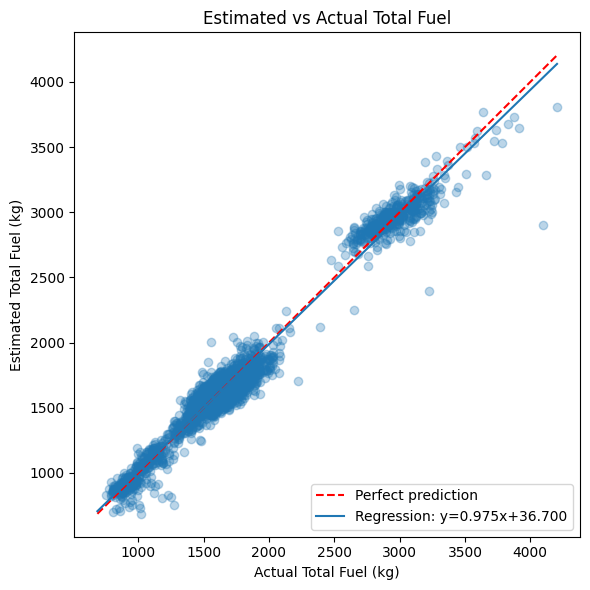

<function matplotlib.pyplot.close(fig: "None | int | str | Figure | Literal['all']" = None) -> 'None'>

In [26]:
plt.figure(figsize=(6, 6))
plt.scatter(pred_all["true_total"], pred_all["pred_total"], alpha=0.3)

min_val = min(pred_all["true_total"].min(), pred_all["pred_total"].min())
max_val = max(pred_all["true_total"].max(), pred_all["pred_total"].max())

plt.plot([min_val, max_val], [min_val, max_val], "r--", label="Perfect prediction")

m, b = np.polyfit(pred_all["true_total"], pred_all["pred_total"], 1)
x_line = np.linspace(min_val, max_val, 100)
plt.plot(x_line, m * x_line + b, label=f"Regression: y={m:.3f}x+{b:.3f}")

plt.xlabel("Actual Total Fuel (kg)")
plt.ylabel("Estimated Total Fuel (kg)")
plt.title("Estimated vs Actual Total Fuel")
plt.legend(loc="lower right")
plt.tight_layout()
out_path = os.path.join("../../outputs", "tot_config3.png")
plt.savefig(out_path, dpi=300)
plt.show()
plt.close


### Residuals


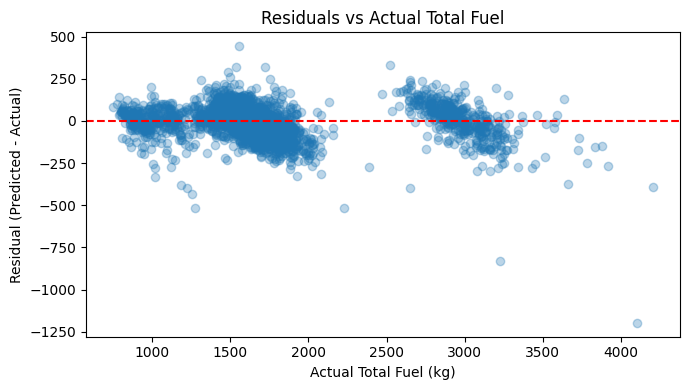

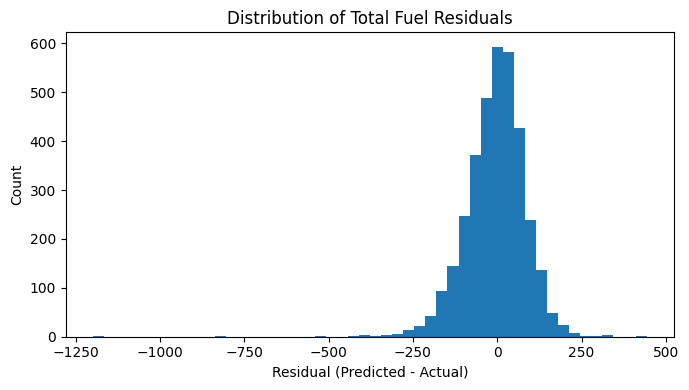

In [20]:
plt.figure(figsize=(7, 4))
plt.scatter(pred_all["true_total"], pred_all["residual"], alpha=0.3)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Actual Total Fuel (kg)")
plt.ylabel("Residual (Predicted - Actual)")
plt.title("Residuals vs Actual Total Fuel")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(pred_all["residual"], bins=50)
plt.xlabel("Residual (Predicted - Actual)")
plt.ylabel("Count")
plt.title("Distribution of Total Fuel Residuals")
plt.tight_layout()
plt.show()


### Average fuel by phase


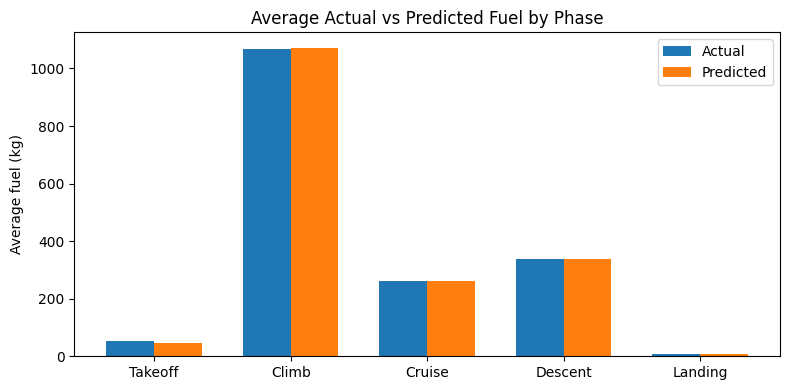

,Phase,Actual,Predicted
0,Takeoff,54.189760,45.493932
1,Climb,1066.954528,1071.889810
2,Cruise,261.159258,259.969960
3,Descent,338.912893,338.464269
4,Landing,9.313330,9.001837


In [21]:
phase_compare = pd.DataFrame({
    "Phase": [phase.capitalize() for phase in PHASES],
    "Actual": [pred_all[f"{phase}_fuel"].mean() for phase in PHASES],
    "Predicted": [pred_all[f"pred_physics_weather_{phase}"].mean() for phase in PHASES],
})

x = np.arange(len(phase_compare))
width = 0.35

plt.figure(figsize=(8, 4))
plt.bar(x - width / 2, phase_compare["Actual"], width=width, label="Actual")
plt.bar(x + width / 2, phase_compare["Predicted"], width=width, label="Predicted")
plt.xticks(x, phase_compare["Phase"])
plt.ylabel("Average fuel (kg)")
plt.title("Average Actual vs Predicted Fuel by Phase")
plt.legend()
plt.tight_layout()
plt.show()

phase_compare


### Phase stacks for selected flights


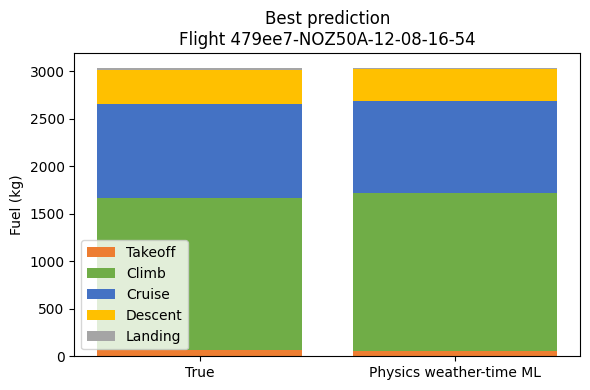

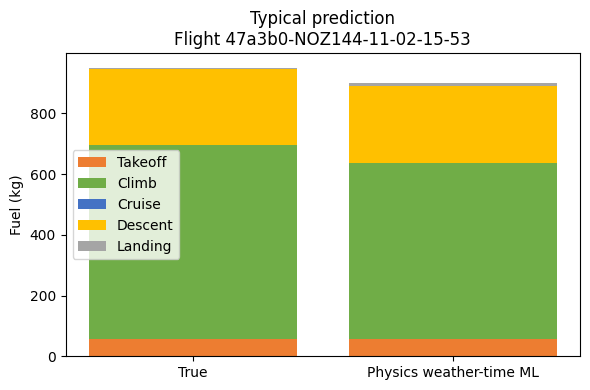

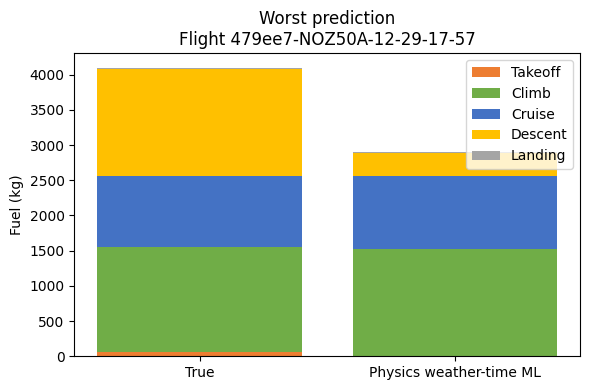

In [22]:
colors = {
    "takeoff_fuel": "#ED7D31",
    "climb_fuel": "#70AD47",
    "cruise_fuel": "#4472C4",
    "descent_fuel": "#FFC000",
    "landing_fuel": "#A5A5A5",
}

best_row = pred_all.sort_values("abs_err", ascending=True).iloc[0]
median_row = pred_all.sort_values("abs_err", ascending=True).iloc[len(pred_all) // 2]
worst_row = pred_all.sort_values("abs_err", ascending=False).iloc[0]

rows_to_plot = [
    ("Best prediction", best_row),
    ("Typical prediction", median_row),
    ("Worst prediction", worst_row),
]


def plot_phase_stack(row, title):
    fig, ax = plt.subplots(figsize=(6, 4))

    bottom_true = 0.0
    bottom_pred = 0.0

    for phase in PHASES:
        true_col = f"{phase}_fuel"
        pred_col = f"pred_physics_weather_{phase}"
        label = phase.capitalize()

        ax.bar("True", row[true_col], bottom=bottom_true, color=colors[true_col], label=label)
        ax.bar("Physics weather-time ML", row[pred_col], bottom=bottom_pred, color=colors[true_col])

        bottom_true += row[true_col]
        bottom_pred += row[pred_col]

    ax.set_ylabel("Fuel (kg)")
    ax.set_title(f"{title}\nFlight {row['flight_id']}")
    ax.legend()
    plt.tight_layout()
    plt.show()


for title, row in rows_to_plot:
    plot_phase_stack(row, title)
